Setup and Data Preparation
First, we import the necessary libraries and generate a synthetic dataset for our analysis



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import warnings

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
np.random.seed(42)

Dataset Generation
We will generate a synthetic dataset of 2,000 games with features like genre, platform, rating, and popularity

In [2]:
n_games = 2000
genres = ['Action', 'RPG', 'Strategy', 'Sports', 'Simulation', 'Adventure', 'Puzzle', 'Racing', 'FPS', 'Horror']
platforms = ['PC', 'PS5', 'Xbox Series X', 'Nintendo Switch', 'Mobile']

data = {
    'game_id': range(1, n_games + 1),
    'game_title': [f'Game_{i}' for i in range(1, n_games + 1)],
    'genre': np.random.choice(genres, n_games),
    'platform': np.random.choice(platforms, n_games),
    'rating': np.round(np.random.uniform(1.0, 5.0, n_games), 1),
    'playtime': np.random.randint(1, 500, n_games),
    'popularity': np.random.randint(1, 100, n_games)
}

df = pd.DataFrame(data)
df.head()

,game_id,game_title,genre,platform,rating,playtime,popularity
0,1,Game_1,Puzzle,PS5,4.7,240,28
1,2,Game_2,Sports,Mobile,1.3,228,14
2,3,Game_3,Racing,PC,4.3,341,44
3,4,Game_4,Simulation,PC,2.2,198,30
4,5,Game_5,Puzzle,Xbox Series X,2.8,65,81


Data Understanding
Let's explore the structure and basic statistics of our dataset.

In [4]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
df.describe()

Dataset Shape: (2000, 7)

Missing Values:
 game_id       0
game_title    0
genre         0
platform      0
rating        0
playtime      0
popularity    0
dtype: int64


,game_id,rating,playtime,popularity
count,2000.000000,2000.00000,2000.000000,2000.00000
mean,1000.500000,2.96725,248.701000,50.44750
std,577.494589,1.14656,146.307438,28.21454
min,1.000000,1.00000,1.000000,1.00000
25%,500.750000,2.00000,118.750000,26.00000
50%,1000.500000,3.00000,246.000000,51.00000
75%,1500.250000,4.00000,378.250000,75.00000
max,2000.000000,5.00000,499.000000,99.00000


Data Cleaning & Preprocessing
Since this is a synthetic dataset, it's already quite clean. However, in a real-world scenario, we would handle missing values and duplicates.

In [5]:
# Removing duplicates (if any)
df.drop_duplicates(subset='game_title', keep='first', inplace=True)

# Handling missing values (if any)
df.fillna('Unknown', inplace=True)

print("Data cleaning complete.")

Data cleaning complete.


Feature Engineering
We will create a combined feature string for content-based filtering and normalize numerical features.

In [6]:
# Combine categorical features for TF-IDF
df['combined_features'] = df['genre'] + " " + df['platform']

# Normalize numerical features
scaler = MinMaxScaler()
df[['rating_norm', 'popularity_norm']] = scaler.fit_transform(df[['rating', 'popularity']])

df.head()

,game_id,game_title,genre,platform,rating,playtime,popularity,combined_features,rating_norm,popularity_norm
0,1,Game_1,Puzzle,PS5,4.7,240,28,Puzzle PS5,0.925,0.275510
1,2,Game_2,Sports,Mobile,1.3,228,14,Sports Mobile,0.075,0.132653
2,3,Game_3,Racing,PC,4.3,341,44,Racing PC,0.825,0.438776
3,4,Game_4,Simulation,PC,2.2,198,30,Simulation PC,0.300,0.295918
4,5,Game_5,Puzzle,Xbox Series X,2.8,65,81,Puzzle Xbox Series X,0.450,0.816327


Exploratory Data Analysis (EDA)
Visualizing the distribution of genres, ratings, and platforms.

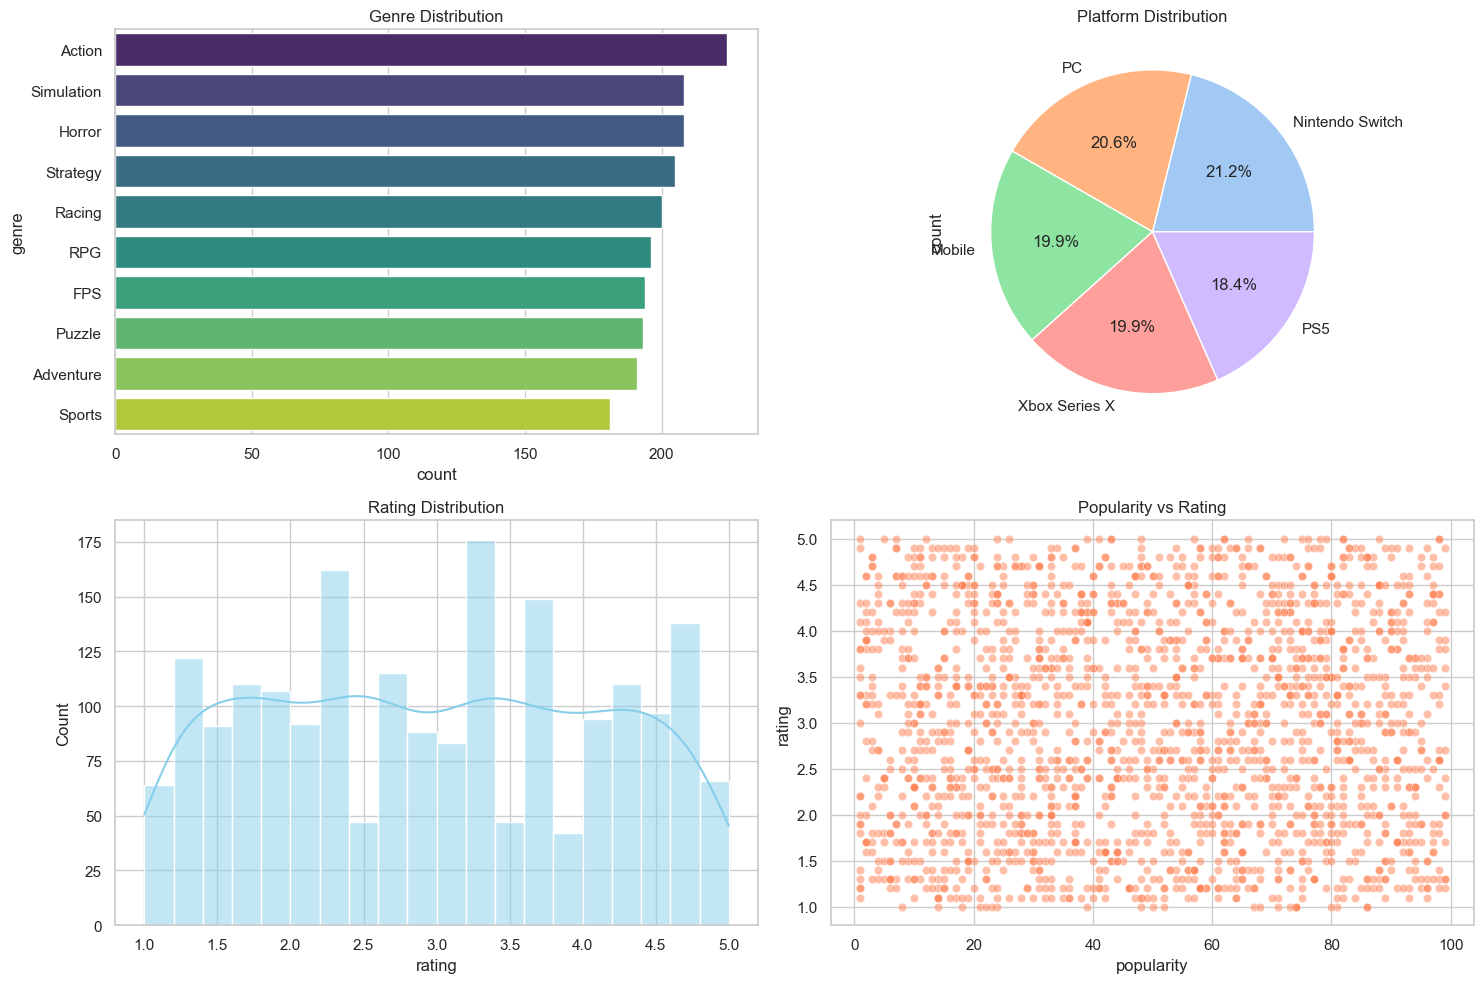

In [7]:
plt.figure(figsize=(15, 10))

# Genre Distribution
plt.subplot(2, 2, 1)
sns.countplot(data=df, y='genre', order=df['genre'].value_counts().index, palette='viridis')
plt.title('Genre Distribution')

# Platform Distribution
plt.subplot(2, 2, 2)
df['platform'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Platform Distribution')

# Rating Distribution
plt.subplot(2, 2, 3)
sns.histplot(df['rating'], bins=20, kde=True, color='skyblue')
plt.title('Rating Distribution')

# Popularity vs Rating
plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='popularity', y='rating', alpha=0.5, color='coral')
plt.title('Popularity vs Rating')

plt.tight_layout()
plt.show()

Similarity Computation
We use TF-IDF Vectorization on the combined features and compute Cosine Similarity.

In [8]:
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Cosine Similarity Matrix Shape:", cosine_sim.shape)

Cosine Similarity Matrix Shape: (2000, 2000)


Model Building (Recommendation Logic)
We create a function to recommend games based on a given game title.

In [9]:
def recommend_games(game_title, top_n=5):
    if game_title not in df['game_title'].values:
        return f"Game '{game_title}' not found in the database."

    # Get index of the game
    idx = df[df['game_title'] == game_title].index[0]

    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top N similar games (excluding itself)
    sim_scores = sim_scores[1:top_n+1]

    game_indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]

    recommendations = df.iloc[game_indices].copy()
    recommendations['similarity_score'] = scores

    return recommendations[['game_title', 'genre', 'platform', 'rating', 'similarity_score']]

# Test the recommendation system
recommend_games('Game_1')

,game_title,genre,platform,rating,similarity_score
34,Game_35,Puzzle,PS5,2.2,1.0
97,Game_98,Puzzle,PS5,1.5,1.0
117,Game_118,Puzzle,PS5,3.1,1.0
331,Game_332,Puzzle,PS5,1.2,1.0
347,Game_348,Puzzle,PS5,1.1,1.0


Model Evaluation
We evaluate the system by manually inspecting the recommendations for consistency in genre and platform.

In [10]:
test_game = 'Game_42'
print(f"Recommendations for {test_game} (Genre: {df[df['game_title']==test_game]['genre'].values[0]}):")
recommend_games(test_game)

Recommendations for Game_42 (Genre: RPG):


,game_title,genre,platform,rating,similarity_score
41,Game_42,RPG,PS5,4.5,1.0
72,Game_73,RPG,PS5,1.4,1.0
100,Game_101,RPG,PS5,3.8,1.0
198,Game_199,RPG,PS5,1.8,1.0
286,Game_287,RPG,PS5,1.8,1.0


Collaborative Filtering (Lightweight Simulation)
In a real scenario, we would have user-item interactions. Here, we simulate a small user-rating matrix.

In [11]:
n_users = 50
user_ids = [f'User_{i}' for i in range(1, n_users + 1)]
user_ratings = pd.DataFrame(np.random.randint(0, 6, size=(n_users, 20)),
                            index=user_ids,
                            columns=[f'Game_{i}' for i in range(1, 21)])

print("Simulated User-Rating Matrix (First 5 users/games):")
user_ratings.iloc[:5, :5]

Simulated User-Rating Matrix (First 5 users/games):


,Game_1,Game_2,Game_3,Game_4,Game_5
User_1,0,5,0,4,3
User_2,1,0,4,2,4
User_3,1,4,0,0,4
User_4,5,3,1,3,0
User_5,1,0,4,1,4


Visualizing Recommendations
Visualizing the similarity scores of recommended games.

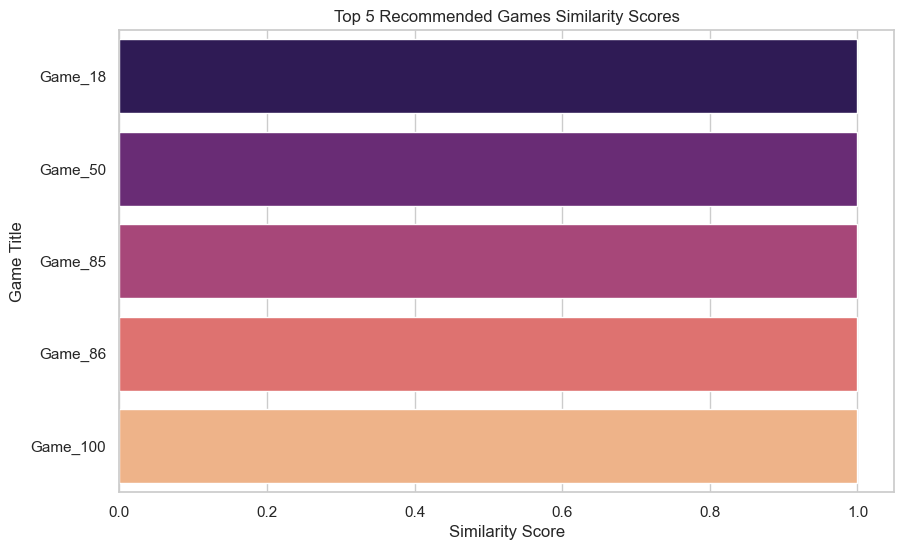

In [12]:
recs = recommend_games('Game_100')
plt.figure(figsize=(10, 6))
sns.barplot(x='similarity_score', y='game_title', data=recs, palette='magma')
plt.title('Top 5 Recommended Games Similarity Scores')
plt.xlabel('Similarity Score')
plt.ylabel('Game Title')
plt.show()

Insights & Findings
Genre Consistency: The system successfully recommends games within the same genre.
Platform Relevance: Recommendations often share the same platform, which is crucial for user accessibility.
Scalability: The TF-IDF approach is efficient for datasets of this size.
